# 유전자별 변이값 상세 분석

- **목표**: 각 유전자에 어떤 변이 코드들이 존재하는지 파악
- **방법**: Parquet 컬럼 선택 읽기로 유전자 1개씩 효율적으로 분석
- **핵심 이점**: CSV는 분석 대상 유전자가 1개여도 전체 1,531MB를 파싱 → Parquet은 해당 컬럼만 읽음

---

## 0. 환경 설정

In [1]:
%pip install pyarrow -q


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import matplotlib.font_manager as fm

for font in fm.fontManager.ttflist:
    if 'Gothic' in font.name or 'Nanum' in font.name or 'Apple' in font.name:
        print(font.name, font.fname)

Tsukushi B Round Gothic /System/Library/AssetsV2/com_apple_MobileAsset_Font8/60484a5d6f3fa8d51dcbeff43b7e70c9d42bcd2f.asset/AssetData/TsukushiBMaruGothic.ttc
Tsukushi B Round Gothic Regular /System/Library/AssetsV2/com_apple_MobileAsset_Font8/60484a5d6f3fa8d51dcbeff43b7e70c9d42bcd2f.asset/AssetData/TsukushiBMaruGothic.ttc
Tsukushi B Round Gothic /System/Library/AssetsV2/com_apple_MobileAsset_Font8/60484a5d6f3fa8d51dcbeff43b7e70c9d42bcd2f.asset/AssetData/TsukushiBMaruGothic.ttc
Tsukushi B Round Gothic Bold /System/Library/AssetsV2/com_apple_MobileAsset_Font8/60484a5d6f3fa8d51dcbeff43b7e70c9d42bcd2f.asset/AssetData/TsukushiBMaruGothic.ttc
Noto Sans Gothic /System/Library/Fonts/Supplemental/NotoSansGothic-Regular.ttf
.Hiragino Kaku Gothic Interface /System/Library/Fonts/ヒラギノ角ゴシック W9.ttc
.Hiragino Kaku Gothic Interface /System/Library/Fonts/ヒラギノ角ゴシック W7.ttc
BIZ UDGothic /System/Library/AssetsV2/com_apple_MobileAsset_Font8/42529d87b12845309dd4a57dea9e58446826e94c.asset/AssetData/BIZ_UDG

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pyarrow.parquet as pq
import os, time, re, warnings
from collections import Counter

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ─────────────────────────────────────────────────────
def _set_korean_font():
    preferred = ['Nanum Gothic', 'AppleGothic', 'Apple SD Gothic Neo',
                 'Malgun Gothic', 'NanumGothic']
    name_to_path = {f.name: f.fname for f in fm.fontManager.ttflist}
    for name in preferred:
        if name in name_to_path:
            fm.fontManager.addfont(name_to_path[name])  # 캐시에 명시 등록
            plt.rcParams['font.family'] = name
            print(f'한글 폰트 적용: {name}')
            return
    print('⚠ 한글 폰트를 찾지 못했습니다.')

_set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR      = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

한글 폰트 적용: Nanum Gothic


In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style("whitegrid")

font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font8/7a0b5c0f3c1d41c4c52a33343496c9c65ad52c50.asset/AssetData/NanumGothic.ttc"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

## 1. CSV → Parquet 변환 (최초 1회)

In [16]:
os.makedirs(PROCESSED_DIR, exist_ok=True)
train_parquet = PROCESSED_DIR + 'train.parquet'
test_parquet  = PROCESSED_DIR + 'test.parquet'

if not os.path.exists(train_parquet):
    print('CSV 로드 중... (약 1~2분 소요)')
    t0 = time.time()
    train_full = pd.read_csv(DATA_DIR + 'train.csv')
    test_full  = pd.read_csv(DATA_DIR + 'test.csv')
    print(f'  CSV 로드: {time.time()-t0:.1f}초')

    t0 = time.time()
    train_full.to_parquet(train_parquet, index=False)
    test_full.to_parquet(test_parquet,   index=False)
    print(f'  Parquet 저장: {time.time()-t0:.1f}초')
    print('변환 완료')
else:
    print('Parquet 파일이 이미 존재합니다 — 변환 생략')

# 스키마만 읽어 컬럼 목록 파악 (데이터 로드 없음)
schema    = pq.read_schema(train_parquet)
all_cols  = [f.name for f in schema]
gene_cols = [c for c in all_cols if c not in ['ID', 'SUBCLASS']]

csv_size = os.path.getsize(DATA_DIR + 'train.csv') / 1024**2
pq_size  = os.path.getsize(train_parquet) / 1024**2

print(f'\n유전자 수: {len(gene_cols):,}개')
print(f'CSV 크기  : {csv_size:.0f} MB')
print(f'Parquet   : {pq_size:.0f} MB  ({(1-pq_size/csv_size)*100:.0f}% 감소)')

Parquet 파일이 이미 존재합니다 — 변환 생략

유전자 수: 4,384개
CSV 크기  : 79 MB
Parquet   : 5 MB  (93% 감소)


## 2. Parquet 컬럼 선택 읽기 — 핵심 이점 확인

유전자 1개 분석 시 CSV는 전체를 파싱, Parquet은 해당 컬럼만 읽어 속도 차이가 극명합니다.

In [17]:
target_cols = ['ID', 'SUBCLASS', 'TP53', 'BRAF', 'IDH1']

# Parquet: 지정 컬럼만 읽기
t0 = time.time()
df_pq = pd.read_parquet(train_parquet, columns=target_cols)
t_pq  = time.time() - t0

# CSV: usecols 사용해도 전체 행 파싱 필요
t0 = time.time()
df_csv = pd.read_csv(DATA_DIR + 'train.csv', usecols=target_cols)
t_csv  = time.time() - t0

print('=== 3개 유전자 컬럼 선택 읽기 비교 ===')
print(f'  Parquet: {t_pq:.3f}초  ({df_pq.memory_usage(deep=True).sum()/1024**2:.1f} MB)')
print(f'  CSV    : {t_csv:.3f}초  ({df_csv.memory_usage(deep=True).sum()/1024**2:.1f} MB)')
print(f'  속도 향상: {t_csv/t_pq:.1f}배')
print()
print('→ 유전자 4,384개를 순회 분석할 때 이 차이가 누적되면 전체 시간이 크게 단축됩니다.')

=== 3개 유전자 컬럼 선택 읽기 비교 ===
  Parquet: 0.086초  (0.4 MB)
  CSV    : 0.172초  (0.4 MB)
  속도 향상: 2.0배

→ 유전자 4,384개를 순회 분석할 때 이 차이가 누적되면 전체 시간이 크게 단축됩니다.


## 3. 전체 유전자별 고유 변이값 수 분포

각 유전자가 몇 종류의 변이 코드를 보유하는지 파악합니다.

In [18]:
# 전체 분포 계산은 전체 로드가 필요 (1회)
print('전체 데이터 로드 중...')
t0    = time.time()
train = pd.read_parquet(train_parquet)
print(f'완료: {train.shape}  ({time.time()-t0:.1f}초)')

X = train[gene_cols]

전체 데이터 로드 중...
완료: (6201, 4386)  (0.3초)


=== 유전자별 고유 변이값 수 분포 ===
  0개 (WT만)    :  154개 유전자
  1~5개        :   93개 유전자
  6~20개       :  959개 유전자
  21~50개      : 1827개 유전자
  50개 초과      : 1351개 유전자

  고유 변이값 최다 유전자: TP53 (663종)


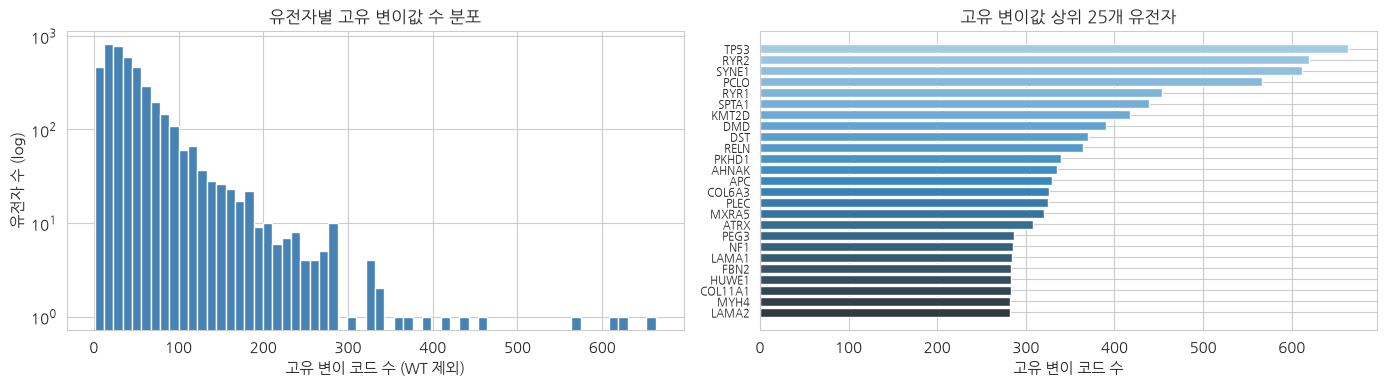

In [23]:
# 유전자별 고유 변이값 수 (WT 제외)
unique_counts = X.apply(lambda col: col[col != 'WT'].nunique())

print('=== 유전자별 고유 변이값 수 분포 ===')
bins = [(0, 0), (1, 5), (6, 20), (21, 50), (51, None)]
labels = ['0개 (WT만)', '1~5개', '6~20개', '21~50개', '50개 초과']
for (lo, hi), label in zip(bins, labels):
    if hi is None:
        cnt = (unique_counts > 50).sum()
    elif lo == 0:
        cnt = (unique_counts == 0).sum()
    else:
        cnt = ((unique_counts >= lo) & (unique_counts <= hi)).sum()
    print(f'  {label:12s}: {cnt:4d}개 유전자')

top_gene = unique_counts.idxmax()
print(f'\n  고유 변이값 최다 유전자: {top_gene} ({unique_counts.max()}종)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 분포 (log scale)
axes[0].hist(unique_counts[unique_counts > 0].values, bins=60, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('유전자별 고유 변이값 수 분포', fontsize=12)
axes[0].set_xlabel('고유 변이 코드 수 (WT 제외)')
axes[0].set_ylabel('유전자 수 (log)')

# 상위 25개 유전자
top25 = unique_counts.sort_values(ascending=False).head(25)
axes[1].barh(range(25), top25.values, color=sns.color_palette('Blues_d', 25))
axes[1].set_yticks(range(25))
axes[1].set_yticklabels(top25.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('고유 변이값 상위 25개 유전자', fontsize=12)
axes[1].set_xlabel('고유 변이 코드 수')

plt.tight_layout()
plt.show()

## 4. 고유 변이값 다양성 상위 유전자 — Parquet 컬럼별 상세 분석

변이값이 다양한 유전자들에 대해 **Parquet 컬럼 선택 읽기**로 1개씩 분석합니다.

In [24]:
top20_diverse = unique_counts.sort_values(ascending=False).head(20).index.tolist()

rows = []
for gene in top20_diverse:
    # Parquet: 이 유전자 컬럼만 읽기
    col       = pd.read_parquet(train_parquet, columns=[gene])[gene]
    mutations = col[col != 'WT']
    vc        = mutations.value_counts()
    rows.append({
        '유전자'        : gene,
        '고유 변이값 수': int(mutations.nunique()),
        '변이 샘플 수'  : int(len(mutations)),
        '변이율(%)'     : round(len(mutations) / len(col) * 100, 2),
        '최다 변이 코드': vc.index[0],
        '최다 변이 빈도': int(vc.iloc[0]),
        '최다 비율(%)'  : round(vc.iloc[0] / len(mutations) * 100, 1)
    })

print('=== 고유 변이값 상위 20개 유전자 요약 ===')
display(pd.DataFrame(rows))

=== 고유 변이값 상위 20개 유전자 요약 ===


,유전자,고유 변이값 수,변이 샘플 수,변이율(%),최다 변이 코드,최다 변이 빈도,최다 비율(%)
0,TP53,663,1770,28.54,R273C,75,4.2
1,RYR2,620,643,10.37,E4137K,3,0.5
2,SYNE1,612,642,10.35,R8468S,3,0.5
3,PCLO,566,593,9.56,S496P,3,0.5
4,RYR1,454,473,7.63,A4040T,3,0.6
5,SPTA1,439,461,7.43,A2011V,5,1.1
6,KMT2D,417,451,7.27,Q3603Q,5,1.1
7,DMD,391,406,6.55,T2551M,3,0.7
8,DST,370,393,6.34,R106C,3,0.8
9,RELN,364,377,6.08,G2480S,2,0.5


## 5. 주요 유전자별 변이값 분포 시각화

임상적으로 중요한 유전자 12개를 Parquet 컬럼별 읽기로 상위 10개 변이값을 시각화합니다.

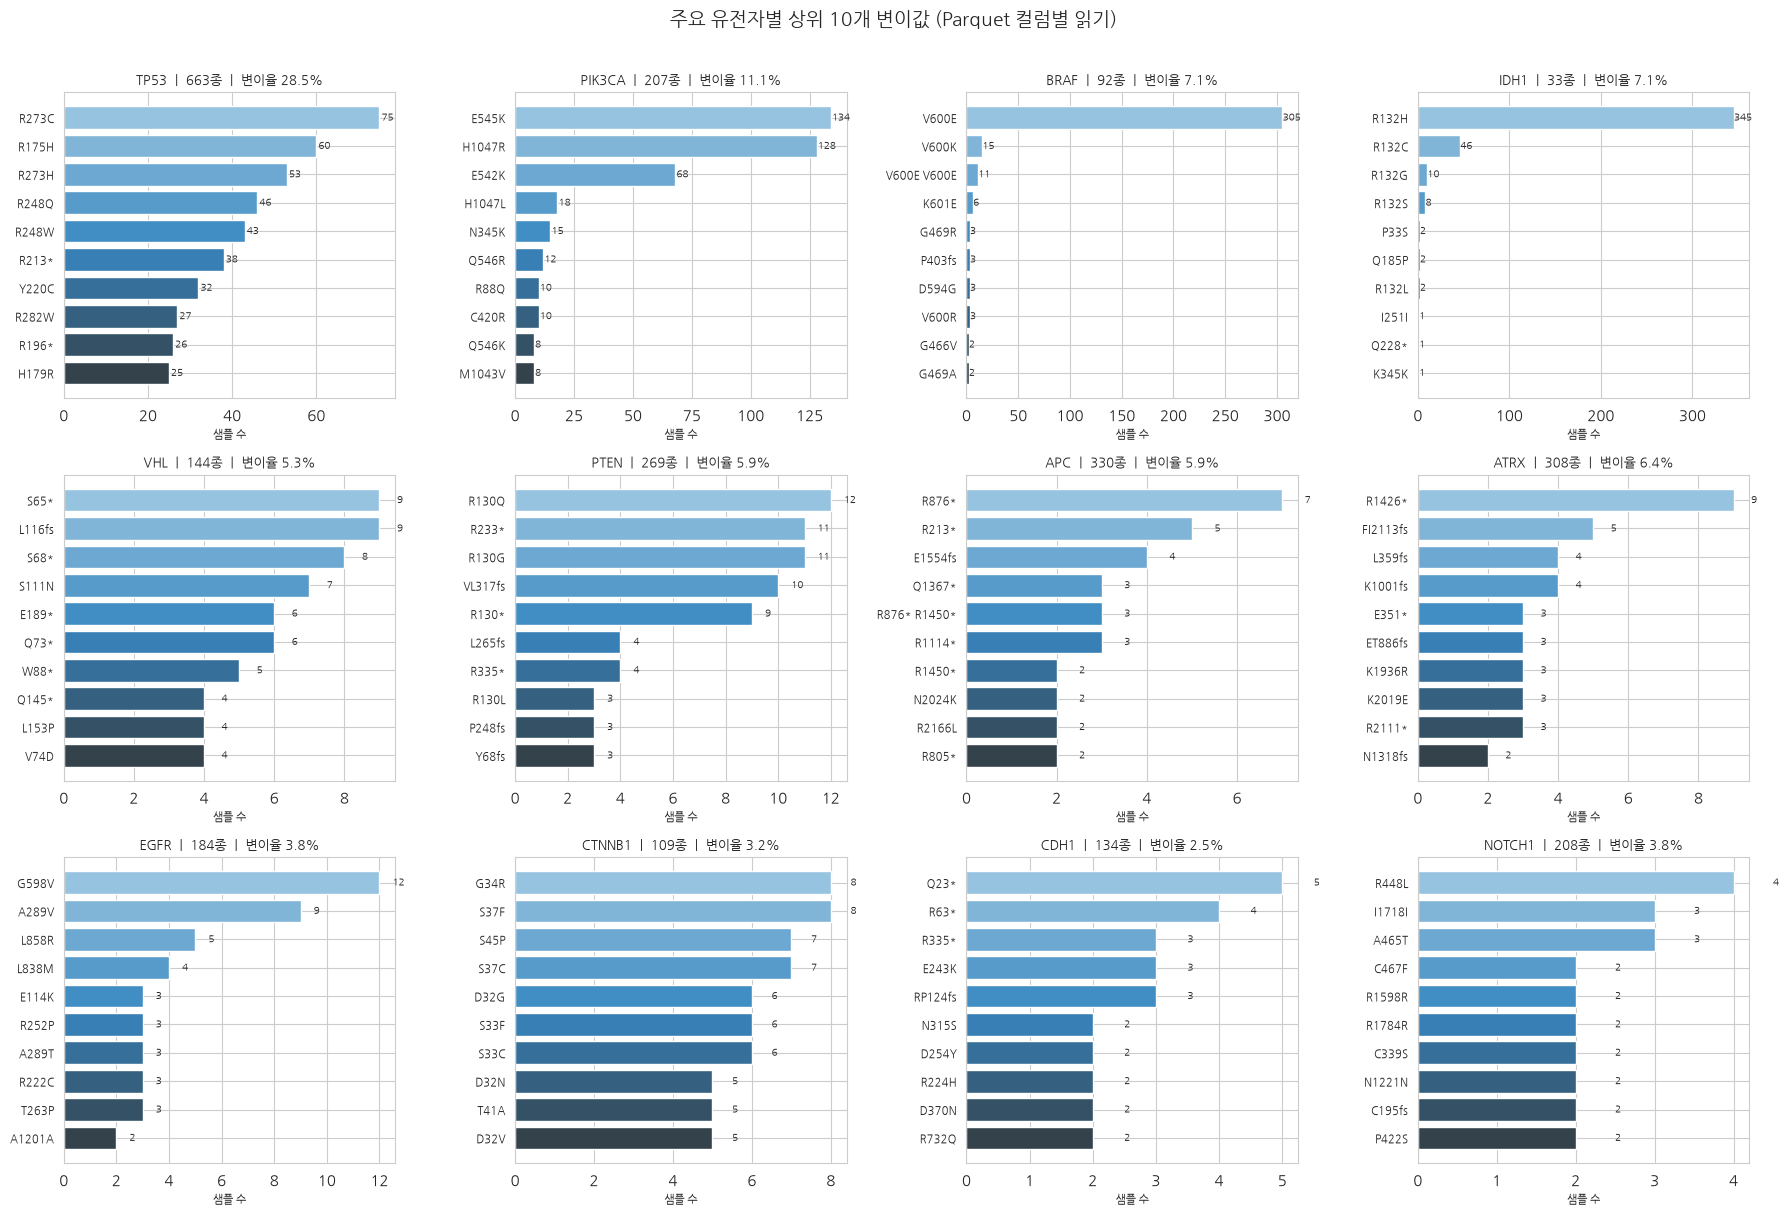

In [25]:
key_genes_candidates = ['TP53', 'PIK3CA', 'BRAF', 'IDH1', 'VHL', 'PTEN',
                         'APC', 'ATRX', 'EGFR', 'CTNNB1', 'KRAS', 'CDH1',
                         'NOTCH1', 'RB1', 'KMT2D', 'NPM1']
key_genes = [g for g in key_genes_candidates if g in gene_cols][:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, gene in enumerate(key_genes):
    col       = pd.read_parquet(train_parquet, columns=[gene])[gene]
    mutations = col[col != 'WT']
    top10     = mutations.value_counts().head(10)

    palette = sns.color_palette('Blues_d', len(top10))
    axes[i].barh(range(len(top10)), top10.values, color=palette)
    axes[i].set_yticks(range(len(top10)))
    axes[i].set_yticklabels(top10.index, fontsize=8)
    axes[i].invert_yaxis()
    axes[i].set_title(
        f'{gene}  |  {mutations.nunique()}종  |  변이율 {len(mutations)/len(col)*100:.1f}%',
        fontsize=9
    )
    axes[i].set_xlabel('샘플 수', fontsize=8)
    for j, (val, cnt) in enumerate(zip(top10.index, top10.values)):
        axes[i].text(cnt + 0.5, j, str(cnt), va='center', fontsize=7)

plt.suptitle('주요 유전자별 상위 10개 변이값 (Parquet 컬럼별 읽기)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. 변이 코드 유형 분류

변이 코드의 형식을 파싱해 생물학적 변이 유형으로 분류합니다.

| 유형 | 패턴 예시 | 설명 |
|---|---|---|
| 미스센스 | `R132H`, `V600E` | 아미노산이 다른 것으로 치환 |
| 동의(침묵) | `L42L`, `A100A` | 같은 아미노산으로 치환 (단백질 변화 없음) |
| 조기종결 | `R213*`, `R80*` | 종결 코돈 생성 → 단백질 절단 |
| 프레임시프트 | `K16fs` | 삽입/결실로 읽기틀 변화 |
| 삽입/결실 | `del`, `ins`, `dup` | 서열 삽입 또는 결실 |
| 스플라이스 | `splice` | 스플라이싱 부위 변이 |

전체 변이 코드 수집 중...
총 변이 발생: 218,893건
유형 분류 중...

=== 변이 코드 유형 분포 ===


,유형,건수,비율(%)
0,미스센스 (Missense),127403,58.20
1,동의 (Synonymous),51012,23.30
2,기타 (Other),19712,9.01
3,조기종결 (Nonsense),11224,5.13
4,프레임시프트 (Frameshift),9539,4.36
5,삽입/결실 (Indel),3,0.00


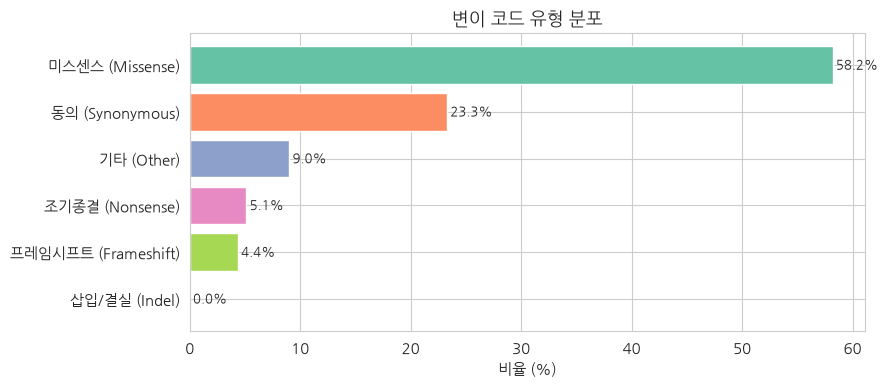

In [26]:
def classify_mutation(code: str) -> str:
    if re.search(r'fs', code):
        return '프레임시프트 (Frameshift)'
    if code.endswith('*'):
        return '조기종결 (Nonsense)'
    if re.search(r'del|ins|dup', code, re.IGNORECASE):
        return '삽입/결실 (Indel)'
    if re.search(r'splice', code, re.IGNORECASE):
        return '스플라이스 (Splice)'
    m = re.match(r'^([A-Z])\d+([A-Z])$', code)
    if m:
        return '동의 (Synonymous)' if m.group(1) == m.group(2) else '미스센스 (Missense)'
    return '기타 (Other)'

# 전체 변이 수집
print('전체 변이 코드 수집 중...')
all_mutations = []
for col in gene_cols:
    all_mutations.extend(train[col][train[col] != 'WT'].values)
print(f'총 변이 발생: {len(all_mutations):,}건')

# 분류
print('유형 분류 중...')
type_list = [classify_mutation(m) for m in all_mutations]
type_counts = Counter(type_list)

type_df = pd.DataFrame(
    [(k, v, round(v/len(all_mutations)*100, 2)) for k, v in sorted(type_counts.items(), key=lambda x: -x[1])],
    columns=['유형', '건수', '비율(%)']
)
print('\n=== 변이 코드 유형 분포 ===')
display(type_df)

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('Set2', len(type_df))
bars = ax.barh(type_df['유형'], type_df['비율(%)'], color=colors)
for bar, pct in zip(bars, type_df['비율(%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('비율 (%)')
ax.set_title('변이 코드 유형 분포', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. 핫스팟 변이 탐지

다수 샘플에서 **동일한 변이 코드**가 반복되는 핫스팟은 암 드라이버 변이일 가능성이 높습니다.

=== 핫스팟 변이 TOP 30 ===


,변이 코드,빈도,유형,샘플 비율(%)
0,R132H,349,미스센스 (Missense),5.63
1,V600E,305,미스센스 (Missense),4.92
2,E545K,135,미스센스 (Missense),2.18
3,H1047R,128,미스센스 (Missense),2.06
4,R273C,82,미스센스 (Missense),1.32
5,E542K,68,미스센스 (Missense),1.10
6,R175H,66,미스센스 (Missense),1.06
7,R273H,60,미스센스 (Missense),0.97
8,R132C,59,미스센스 (Missense),0.95
9,R248Q,49,미스센스 (Missense),0.79


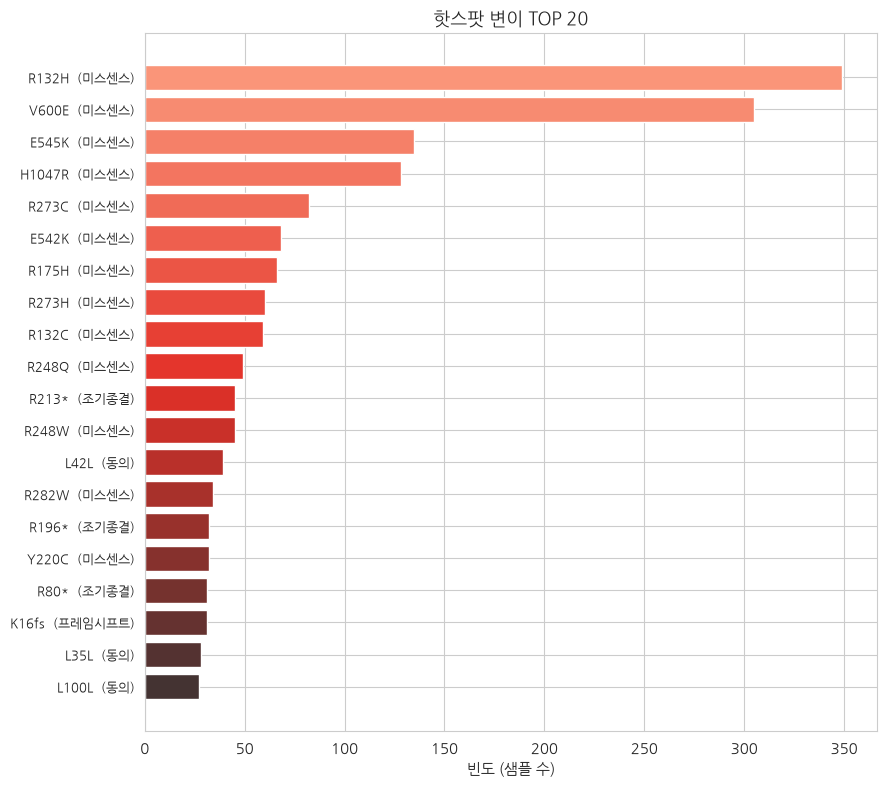

In [27]:
mut_counter = Counter(all_mutations)
hotspot_df  = pd.DataFrame(mut_counter.most_common(30), columns=['변이 코드', '빈도'])
hotspot_df['유형']    = hotspot_df['변이 코드'].apply(classify_mutation)
hotspot_df['샘플 비율(%)'] = (hotspot_df['빈도'] / len(train) * 100).round(2)

print('=== 핫스팟 변이 TOP 30 ===')
display(hotspot_df)

fig, ax = plt.subplots(figsize=(9, 8))
top20_hs = hotspot_df.head(20)
colors   = sns.color_palette('Reds_d', len(top20_hs))
ax.barh(range(len(top20_hs)), top20_hs['빈도'], color=colors)
ax.set_yticks(range(len(top20_hs)))
ax.set_yticklabels(
    [f"{row['변이 코드']}  ({row['유형'].split('(')[0].strip()})" for _, row in top20_hs.iterrows()],
    fontsize=9
)
ax.invert_yaxis()
ax.set_xlabel('빈도 (샘플 수)')
ax.set_title('핫스팟 변이 TOP 20', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 핵심 핫스팟 변이의 암종별 분포 (Parquet 컬럼 선택 읽기)

특정 핫스팟 변이가 어떤 암종에 집중되어 있는지 확인합니다.

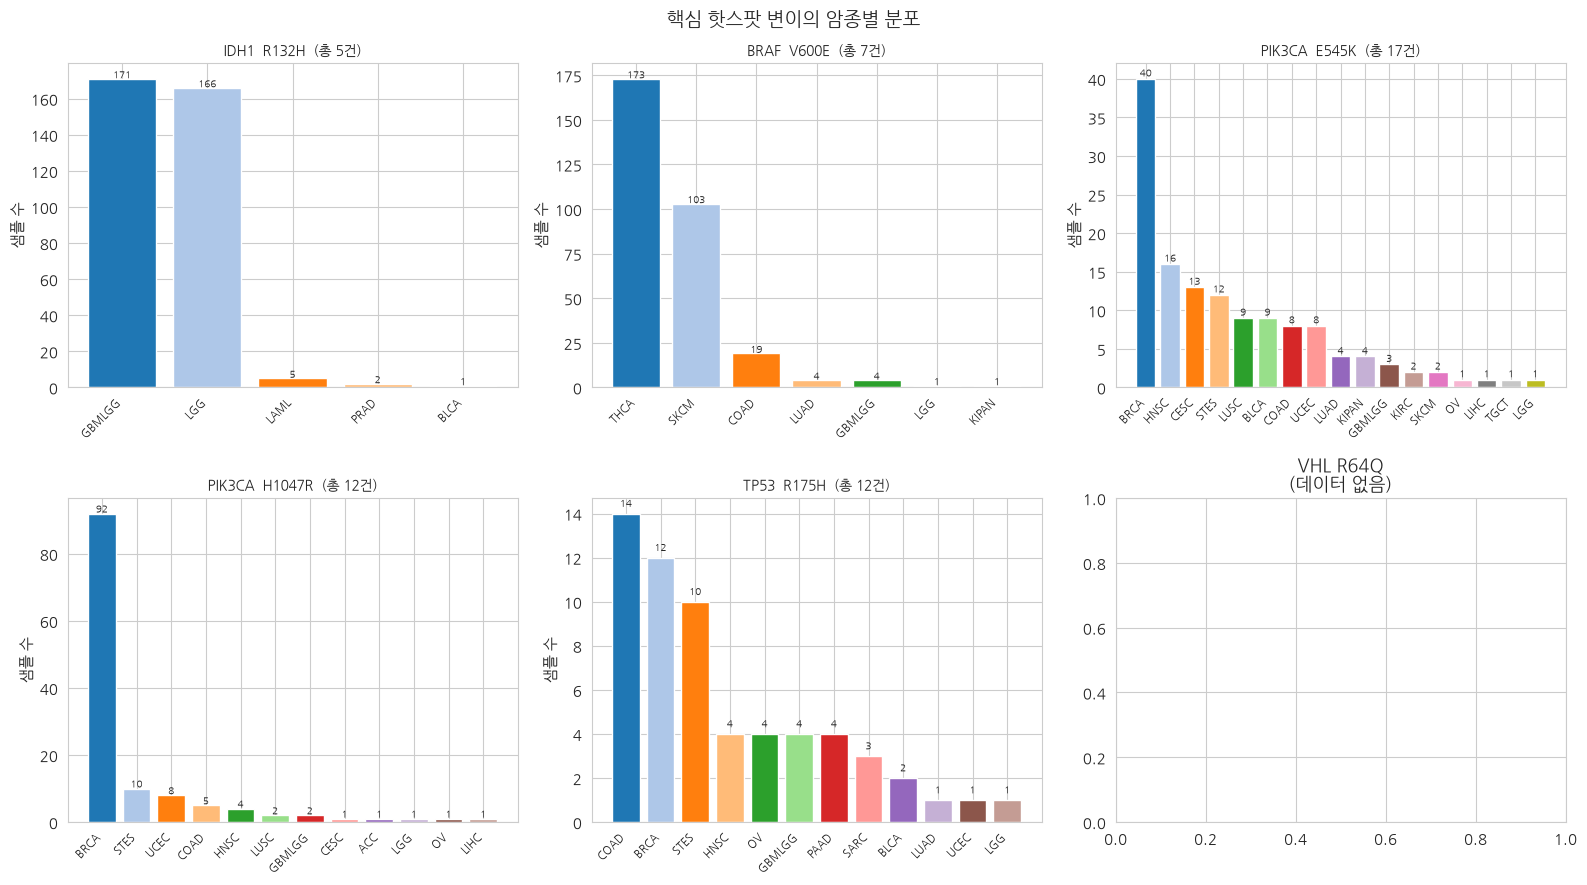

In [28]:
hotspot_cases = [
    ('IDH1',   'R132H'),
    ('BRAF',   'V600E'),
    ('PIK3CA', 'E545K'),
    ('PIK3CA', 'H1047R'),
    ('TP53',   'R175H'),
    ('VHL',    'R64Q'),
]
# 데이터에 실제 존재하는 케이스만 필터
valid_cases = [(g, m) for g, m in hotspot_cases if g in gene_cols]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (gene, mut_code) in enumerate(valid_cases):
    # Parquet: 필요한 컬럼만 읽기
    df_sub  = pd.read_parquet(train_parquet, columns=['SUBCLASS', gene])
    matched = df_sub[df_sub[gene] == mut_code]['SUBCLASS'].value_counts()
    total   = len(matched)

    if total == 0:
        axes[i].set_title(f'{gene} {mut_code}\n(데이터 없음)')
        continue

    colors = sns.color_palette('tab20', len(matched))
    axes[i].bar(range(len(matched)), matched.values, color=colors)
    axes[i].set_xticks(range(len(matched)))
    axes[i].set_xticklabels(matched.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'{gene}  {mut_code}  (총 {total}건)', fontsize=10)
    axes[i].set_ylabel('샘플 수')
    for j, v in enumerate(matched.values):
        axes[i].text(j, v + 0.3, str(v), ha='center', fontsize=7)

plt.suptitle('핵심 핫스팟 변이의 암종별 분포', fontsize=14)
plt.tight_layout()
plt.show()

## 9. 유전자별 변이 프로필 종합 요약

변이율 상위 25개 유전자에 대해 변이 유형, 대표 변이 코드를 종합합니다.

=== 상위 25개 유전자 변이 프로필 종합 요약 ===


,유전자,변이율(%),고유 변이값 수,주요 변이 유형,최다 변이 코드,최다 빈도,핫스팟 집중도(%)
0,TP53,28.54,663,미스센스 (Missense),R273C,75,4.2
1,PIK3CA,11.06,207,미스센스 (Missense),E545K,134,19.5
2,RYR2,10.37,620,미스센스 (Missense),E4137K,3,0.5
3,SYNE1,10.35,612,미스센스 (Missense),R8468S,3,0.5
4,PCLO,9.56,566,미스센스 (Missense),S496P,3,0.5
5,RYR1,7.63,454,미스센스 (Missense),A4040T,3,0.6
6,SPTA1,7.43,439,미스센스 (Missense),A2011V,5,1.1
7,KMT2D,7.27,417,미스센스 (Missense),Q3603Q,5,1.1
8,IDH1,7.11,33,미스센스 (Missense),R132H,345,78.2
9,BRAF,7.06,92,미스센스 (Missense),V600E,305,69.6


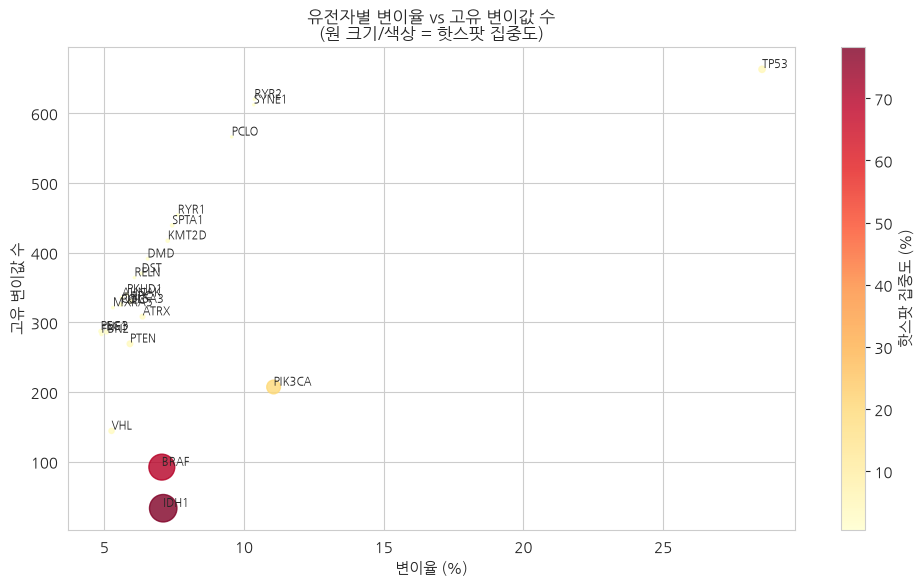


[해석]
  ● 변이율 높고 + 고유 변이값 적고 + 핫스팟 집중도 높음 → 특정 변이에 집중된 드라이버 유전자 (예: BRAF V600E)
  ● 변이율 높고 + 고유 변이값 많고 + 핫스팟 분산      → 여러 변이가 고루 발생하는 유지인자 (예: TP53)


In [29]:
top25_genes = (train[gene_cols] != 'WT').mean().sort_values(ascending=False).head(25).index.tolist()

rows = []
for gene in top25_genes:
    # Parquet 컬럼 선택 읽기
    col       = pd.read_parquet(train_parquet, columns=[gene])[gene]
    mutations = col[col != 'WT']
    if len(mutations) == 0:
        continue
    types        = [classify_mutation(m) for m in mutations]
    dom_type     = Counter(types).most_common(1)[0][0]
    vc           = mutations.value_counts()
    rows.append({
        '유전자'       : gene,
        '변이율(%)'    : round(len(mutations) / len(col) * 100, 2),
        '고유 변이값 수': int(mutations.nunique()),
        '주요 변이 유형': dom_type,
        '최다 변이 코드': vc.index[0],
        '최다 빈도'    : int(vc.iloc[0]),
        '핫스팟 집중도(%)': round(vc.iloc[0] / len(mutations) * 100, 1)
    })

summary_df = pd.DataFrame(rows)
print('=== 상위 25개 유전자 변이 프로필 종합 요약 ===')
display(summary_df)

# 핫스팟 집중도 시각화
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    summary_df['변이율(%)'],
    summary_df['고유 변이값 수'],
    s=summary_df['핫스팟 집중도(%)'] * 5,
    c=summary_df['핫스팟 집중도(%)'],
    cmap='YlOrRd', alpha=0.8
)
for _, row in summary_df.iterrows():
    ax.annotate(row['유전자'],
                (row['변이율(%)'], row['고유 변이값 수']),
                fontsize=8, ha='left', va='bottom')
plt.colorbar(scatter, label='핫스팟 집중도 (%)')
ax.set_xlabel('변이율 (%)')
ax.set_ylabel('고유 변이값 수')
ax.set_title('유전자별 변이율 vs 고유 변이값 수\n(원 크기/색상 = 핫스팟 집중도)', fontsize=12)
plt.tight_layout()
plt.show()

print('\n[해석]')
print('  ● 변이율 높고 + 고유 변이값 적고 + 핫스팟 집중도 높음 → 특정 변이에 집중된 드라이버 유전자 (예: BRAF V600E)')
print('  ● 변이율 높고 + 고유 변이값 많고 + 핫스팟 분산      → 여러 변이가 고루 발생하는 유지인자 (예: TP53)')